<a href="https://colab.research.google.com/github/nitha604/movie_recommendation/blob/main/DLT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [2]:
!wget http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip

ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")


--2026-03-22 09:19:44--  http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-latest-small.zip [following]
--2026-03-22 09:19:44--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  3.33MB/s    in 0.3s    

2026-03-22 09:19:44 (3.33 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



In [3]:
user_ids = ratings["userId"].unique().tolist()
movie_ids = ratings["movieId"].unique().tolist()

user_to_index = {x: i for i, x in enumerate(user_ids)}
movie_to_index = {x: i for i, x in enumerate(movie_ids)}

ratings["user"] = ratings["userId"].map(user_to_index)
ratings["movie"] = ratings["movieId"].map(movie_to_index)


In [4]:
ratings["rating"] = ratings["rating"].astype(np.float32)
min_rating = ratings["rating"].min()
max_rating = ratings["rating"].max()

ratings["rating"] = (ratings["rating"] - min_rating) / (max_rating - min_rating)


In [5]:
movies["genres"] = movies["genres"].str.split("|")

all_genres = set(g for sublist in movies["genres"] for g in sublist)
genre_to_index = {g: i for i, g in enumerate(all_genres)}

def encode_genres(genres):
    vec = np.zeros(len(all_genres))
    for g in genres:
        vec[genre_to_index[g]] = 1
    return vec

movies["genre_vector"] = movies["genres"].apply(encode_genres)


In [6]:
ratings = ratings.merge(movies[["movieId", "genre_vector"]], on="movieId")
genre_data = np.stack(ratings["genre_vector"].values)


In [7]:
ratings = ratings.sample(frac=1, random_state=42)

train_size = int(0.8 * len(ratings))

train = ratings[:train_size]
test = ratings[train_size:]

x_train = train[["user", "movie"]].values
y_train = train["rating"].values

x_test = test[["user", "movie"]].values
y_test = test["rating"].values

x_train_genre = genre_data[:train_size]
x_test_genre = genre_data[train_size:]


In [8]:
num_users = len(user_ids)
num_movies = len(movie_ids)
embedding_size = 50

# Inputs
user_input = keras.Input(shape=(1,))
movie_input = keras.Input(shape=(1,))
genre_input = keras.Input(shape=(len(all_genres),))

# Embeddings
user_embedding = layers.Embedding(num_users, embedding_size)(user_input)
movie_embedding = layers.Embedding(num_movies, embedding_size)(movie_input)

user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

# GMF (Generalized Matrix Factorization)
gmf = layers.Multiply()([user_vec, movie_vec])

# MLP part (Neural Network)
mlp = layers.Concatenate()([user_vec, movie_vec, genre_input])
mlp = layers.Dense(128, activation='relu')(mlp)
mlp = layers.Dense(64, activation='relu')(mlp)

# Combine both (NCF)
x = layers.Concatenate()([gmf, mlp])

# Output
output = layers.Dense(1, activation='sigmoid')(x)

# Model
model = keras.Model([user_input, movie_input, genre_input], output)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['mae']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,200 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 120)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     15,488 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50)        │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 114)       │          0 │ multiply[0][0],   │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        115 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 540,559 (2.06 MB)

 Trainable params: 540,559 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    [x_train[:,0], x_train[:,1], x_train_genre],
    y_train,
    batch_size=64,
    epochs=5,
    validation_data=([x_test[:,0], x_test[:,1], x_test_genre], y_test)
)


Epoch 1/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.6068 - mae: 0.1568 - val_loss: 0.6016 - val_mae: 0.1501
Epoch 2/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.5911 - mae: 0.1411 - val_loss: 0.6002 - val_mae: 0.1478
Epoch 3/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.5824 - mae: 0.1325 - val_loss: 0.6016 - val_mae: 0.1500
Epoch 4/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.5729 - mae: 0.1229 - val_loss: 0.6062 - val_mae: 0.1544
Epoch 5/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.5632 - mae: 0.1130 - val_loss: 0.6137 - val_mae: 0.1564


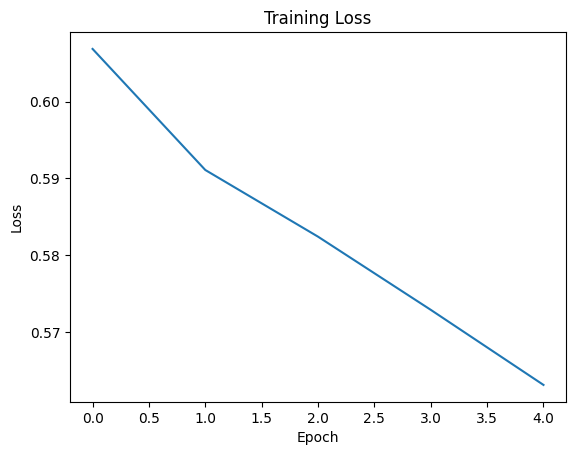

In [10]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [11]:
def recommend_movies(user_id, num_recommendations=5):
    user_idx = user_to_index[user_id]

    movie_indices = np.array(list(movie_to_index.values()))
    user_array = np.array([user_idx] * len(movie_indices))

    genre_vectors = np.array([
        movies.loc[movies["movieId"] == mid, "genre_vector"].values[0]
        for mid in movie_to_index.keys()
    ])

    predictions = model.predict([user_array, movie_indices, genre_vectors]).flatten()

    top_indices = predictions.argsort()[-num_recommendations:][::-1]

    movie_ids_list = list(movie_to_index.keys())
    recommended_ids = [movie_ids_list[i] for i in top_indices]

    return movies[movies["movieId"].isin(recommended_ids)][["title", "genres"]]


# 👉 Give input here
recommend_movies(user_id=1)


304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,title,genres
796,Secrets & Lies (1996),[Drama]
4396,"Trial, The (Procès, Le) (1962)",[Drama]
4782,Adam's Rib (1949),"[Comedy, Romance]"
5497,Harlan County U.S.A. (1976),[Documentary]
9318,Planet Earth (2006),[Documentary]


In [12]:
y_pred = model.predict([x_test[:,0], x_test[:,1], x_test_genre]).flatten()

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [14]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAE
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)


RMSE: 0.20549867288829224
MAE: 0.15635019540786743
